# 04a: CNN epoch-cap sensitivity and methodological adequacy

```bat
venv\Scripts\python.exe -m pip install torch==2.14.0 torchvision==0.29.0 numpy pandas matplotlib pillow scikit-learn
```

This single controlled sensitivity check changes only the maximum epoch cap from 25 to 40. It preserves notebook 04's architecture, preprocessing, AdamW, learning rate, batch size, dropout, cross-entropy loss, fixed 02a folds, seeds and strict macro-F1 early stopping. All five folds start afresh. No locked test pixels, predictions or evaluation are accessed. Existing split metadata are read only to enforce the development permission boundary.

**Rationale:** three original folds reached epoch 25, but one also satisfied patience at that epoch. Only two were stopped solely by the ceiling. A ceiling alone is not evidence of undertraining. This check investigates training-budget adequacy, not score maximisation.

## Predeclared decision rule

Thresholds below are pragmatic absolute macro-F1 differences, not significance levels. They are declared before this run, after identifying the original cap concern.

* Adopt 40 if at least two folds each improve by at least 0.005, those folds originally stopped solely at the ceiling, and their new selected epochs exceed 25. This provides concordant evidence of material improvement and original truncation.
* Retain 25 as adequate under this check if the absolute mean change is at most 0.002, no fold improves by at least 0.005, and at least three folds stop through the unchanged patience rule before epoch 40. Natural plateau means no strictly improved validation F1 for five epochs, not a claim of global convergence. Loss trajectories are supporting diagnostics only.
* Otherwise retain 25 provisionally and report inconclusive adequacy. Do not disguise mixed evidence as equivalence or run further caps.
* If the common training prefix fails to reproduce within 1e-10 or software/hardware provenance differs, qualify causal attribution and do not automatically revise the specification.

All outcomes, including worse results, are retained. No further caps or hyperparameter changes follow this result. No final development refit occurs here; the saved decision records the maximum cap and carries forward the original ceiling-of-median refit rule. A later refit, if needed, is separate from this adequacy check.

Fold SD uses ddof=1. These overlapping folds, one seed per fold and validation-selected checkpoints do not provide an independent test estimate or a confidence interval. The check is motivated by observed development behaviour and adds selection optimism. Earlier full-collection EDA, uncertain acquisition independence and absent normal-steel examples remain limitations.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
from time import perf_counter
from importlib.metadata import version
import hashlib
import json
import math
import os
import platform
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay

ROOT = Path.cwd().resolve()
METRICS = ROOT / 'outputs' / 'metrics'
REPORTS = ROOT / 'outputs' / 'reports'
CLASSES = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled_in_scale', 'scratches']
CLASS_TO_INDEX = {name: i for i, name in enumerate(CLASSES)}
CHECKS = []
def require(name, passed, detail=''):
    CHECKS.append({'check': name, 'status': 'PASS' if bool(passed) else 'FAIL', 'detail': str(detail)})
    if not bool(passed):
        if 'RUN' in globals():
            pd.DataFrame(CHECKS).to_csv(RUN/'acceptance_checks.csv', index=False)
            (RUN/'status.json').write_text(json.dumps({'status':'FAIL','failed_check':name}), encoding='utf-8')
        raise RuntimeError(f'{name}: {detail}')
def file_sha(path):
    h=hashlib.sha256()
    with path.open('rb') as handle:
        for block in iter(lambda: handle.read(1024*1024), b''): h.update(block)
    return h.hexdigest()
def read_json(path): return json.loads(path.read_text(encoding='utf-8'))
def write_json(path, value):
    temporary=path.with_suffix(path.suffix+'.tmp')
    temporary.write_text(json.dumps(value,indent=2,allow_nan=False), encoding='utf-8')
    temporary.replace(path)

ARTIFACTS = {
    'manifest': METRICS/'data_split_manifest.csv', 'split_lock': METRICS/'split_lock.json',
    'folds': METRICS/'development_cv_folds.csv', 'fold_lock': METRICS/'development_cv_lock.json',
    'split_status': REPORTS/'02_split_status.json', 'fold_status': REPORTS/'02a_validation_status.json',
    'classical_pointer': REPORTS/'03_classical_latest.json'}
require('Required preparation artefacts exist', all(p.is_file() for p in ARTIFACTS.values()))
source_hashes={name:file_sha(path) for name,path in ARTIFACTS.items()}
split_lock=read_json(ARTIFACTS['split_lock'])
fold_lock=read_json(ARTIFACTS['fold_lock'])
split_status=read_json(ARTIFACTS['split_status'])
fold_status=read_json(ARTIFACTS['fold_status'])
require('Preparation passed', split_status['status']==fold_status['status']=='PASS')
require('Split hashes agree', source_hashes['manifest']==split_lock['manifest_sha256']==fold_lock['split_manifest_sha256']
        ==split_status['manifest_sha256']==fold_status['split_manifest_sha256'])
require('Fold hashes agree', source_hashes['folds']==fold_lock['folds_sha256']==fold_status['folds_sha256'])
require('Fixed protocol recognised', split_lock['classes']==CLASSES and split_lock['seed']==fold_lock['seed']==42
        and fold_lock['n_folds']==5 and split_lock['test_size']==0.2)
classical_pointer=read_json(ARTIFACTS['classical_pointer'])
classical_run=(ROOT/classical_pointer['run_directory']).resolve()
require('Classical result path inside outputs', classical_run.is_relative_to(ROOT/'outputs'))
classical_result_path=classical_run/'result.json'
require('Classical result verified', file_sha(classical_result_path)==classical_pointer['result_sha256'])
classical_result=read_json(classical_result_path)
require('Same folds as classical model', classical_result['status']=='PASS' and
        classical_result['source_digests']['manifest']==source_hashes['manifest'] and
        classical_result['source_digests']['folds']==source_hashes['folds'] and
        classical_result['test_evaluation_performed'] is False)
ARTIFACTS['classical_result']=classical_result_path
source_hashes['classical_result']=file_sha(classical_result_path)

manifest=pd.read_csv(ARTIFACTS['manifest'],keep_default_na=False)
folds=pd.read_csv(ARTIFACTS['folds'],keep_default_na=False)
require('Manifest path uniqueness', manifest.path.is_unique and folds.path.is_unique)
development=manifest.loc[manifest.split.eq('development')].sort_values('path').reset_index(drop=True)
require('Development count and classes', len(development)==1439 and set(development.class_name)==set(CLASSES))
require('Folds exactly cover development', set(folds.path)==set(development.path))
folds=folds.set_index('path').loc[development.path].reset_index()
for column in ['path','class_name','sha256','pixel_sha256']:
    require(f'Fold metadata agrees: {column}', folds[column].equals(development[column]))
development['validation_fold']=folds.validation_fold.to_numpy()
require('Exactly five predefined folds', set(development.validation_fold)==set(range(5)))
for column in ['sha256','pixel_sha256']:
    require(f'Unique development content: {column}', development[column].is_unique)
ALLOWED_PATHS=frozenset(development.path)
NON_DEVELOPMENT_PATHS=frozenset(manifest.loc[~manifest.split.eq('development'),'path'])
require('Development permission boundary disjoint', not ALLOWED_PATHS & NON_DEVELOPMENT_PATHS)
FOLD_INDICES=[]
for fold in range(5):
    train=np.flatnonzero(development.validation_fold.to_numpy()!=fold)
    valid=np.flatnonzero(development.validation_fold.to_numpy()==fold)
    require(f'Fold {fold}: disjoint and complete', not set(train)&set(valid) and len(train)+len(valid)==1439)
    require(f'Fold {fold}: all six classes', set(development.iloc[train].class_name)==set(development.iloc[valid].class_name)==set(CLASSES))
    FOLD_INDICES.append((train,valid))
require('Validation coverage exactly once', np.array_equal(np.sort(np.concatenate([v for _,v in FOLD_INDICES])),np.arange(1439)))
require('Locked partition has 360 metadata rows', int(manifest.split.eq('test').sum())==360)
# Remove the full manifest so modelling functions cannot accidentally select its test rows.
del manifest, folds
print('PASS: same locked split and five folds as HOG-SVM; no image files opened yet.')

PASS: same locked split and five folds as HOG-SVM; no image files opened yet.


## Verify and freeze the original development reference
The latest successful notebook 04 result is selected by its saved pointer, not by score. Original histories and metrics are copied unchanged into the new run. No original checkpoints or results are overwritten.

In [2]:
BASE_POINTER=REPORTS/'04_cnn_latest.json'
baseline_pointer=read_json(BASE_POINTER)
BASE=(ROOT/baseline_pointer['run_directory']).resolve()
require('Baseline inside experiment outputs', BASE.is_relative_to(ROOT/'outputs'/'experiments'))
require('Baseline result digest matches', file_sha(BASE/'result.json')==baseline_pointer['result_sha256'])
baseline_result=read_json(BASE/'result.json')
baseline_protocol=read_json(BASE/'protocol.json')
baseline_metrics=pd.read_csv(BASE/'fold_metrics.csv').sort_values('fold').reset_index(drop=True)
baseline_history=pd.read_csv(BASE/'all_fold_histories.csv')
require('Baseline is successful development-only five-fold run', baseline_result['status']=='PASS' and baseline_result['test_evaluation_performed'] is False and baseline_metrics.fold.tolist()==list(range(5)))
require('Baseline maximum cap was 25', baseline_protocol['config']['max_epochs']==25)
require('Baseline uses identical source protocol', all(baseline_result['source_hashes'][k]==source_hashes[k] for k in ['manifest','folds','split_lock','fold_lock']))
for label,name in [('baseline_pointer',None),('baseline_result','result.json'),('baseline_protocol','protocol.json'),('baseline_metrics','fold_metrics.csv'),('baseline_history','all_fold_histories.csv')]:
    ARTIFACTS[label]=BASE/name if name else BASE_POINTER
    source_hashes[label]=file_sha(ARTIFACTS[label])
ARTIFACTS['original_notebook']=ROOT/'04_deep_learning_cnn.ipynb'
source_hashes['original_notebook']=file_sha(ARTIFACTS['original_notebook'])
print('Frozen reference:',BASE.name)
display(baseline_metrics[['fold','best_epoch','epochs_run','stop_reason','f1_macro']])

Frozen reference: 04_cnn_20260925T222923_890724Z


,fold,best_epoch,epochs_run,stop_reason,f1_macro
0,0,20,25,patience,0.965152
1,1,15,20,patience,0.927876
2,2,8,13,patience,0.893120
3,3,23,25,epoch_limit,0.954774
4,4,23,25,epoch_limit,0.947815


In [3]:
DEVICE=torch.device('cpu')
CONFIG={'seed':42,'channels':[8,16,32],'input_shape':[1,200,200],
        'first_conv_stride':2,'dropout':0.25,'learning_rate':0.001,'weight_decay':0.0001,
        'batch_size':32,'max_epochs':40,'patience':5,'threads':min(4,os.cpu_count() or 1),
        'num_workers':0,'augmentation':'none','selection':'strictly highest validation macro F1; earliest tie',
        'refit_epoch_rule':'ceiling of median best fold epoch'}
torch.set_num_threads(CONFIG['threads'])
torch.use_deterministic_algorithms(True)
def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
seed_everything(CONFIG['seed'])
environment={'python':platform.python_version(),'executable':sys.executable,'platform':platform.platform(),
    'processor':platform.processor(),'logical_cpus':os.cpu_count(),'torch_threads':torch.get_num_threads(),
    'device':str(DEVICE),'cuda_available':torch.cuda.is_available(),
    'deterministic_algorithms':torch.are_deterministic_algorithms_enabled(),
    'packages':{p:version(p) for p in ['torch','torchvision','numpy','pandas','matplotlib','pillow','scikit-learn']}}
try: environment['packages']['captum']=version('captum')
except Exception: environment['packages']['captum']='not installed; optional for later explanations'
run_id=datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')
RUN=ROOT/'outputs'/'experiments'/('04a_cnn_epoch_sensitivity_'+run_id)
RUN.mkdir(parents=True,exist_ok=False)
(RUN/'checkpoints').mkdir()
write_json(RUN/'status.json',{'status':'IN_PROGRESS','stage':'safeguards'})
write_json(RUN/'protocol.json',{'run_id':run_id,'config':CONFIG,'classes':CLASSES,
    'class_to_index':CLASS_TO_INDEX,'source_hashes':source_hashes,'environment':environment,
    'interpretation':'development checkpoint selection, not final test or nested validation'})
print('Run:',RUN)
print(json.dumps(environment,indent=2))
require('Only maximum epochs changed', {k:v for k,v in CONFIG.items() if k!='max_epochs'}=={k:v for k,v in baseline_protocol['config'].items() if k!='max_epochs'})
environment_matches=all(environment[k]==baseline_protocol['environment'][k] for k in ['python','platform','processor','logical_cpus','torch_threads','device','deterministic_algorithms','packages'])
DECISION_RULE={'material_fold_delta':0.005,'negligible_absolute_mean_delta':0.002,'several_folds':2,'natural_plateau_folds':3,'prefix_tolerance':1e-10,'mixed_evidence':'retain 25 provisionally; inconclusive','additional_caps_permitted':False}
write_json(RUN/'predeclared_decision_rule.json',{'declared_at_utc':datetime.now(timezone.utc).isoformat(),'rule':DECISION_RULE,'baseline_run':BASE.name,'environment_matches':environment_matches,'source_hashes':source_hashes})
declaration_sha=file_sha(RUN/'predeclared_decision_rule.json')
for name in ['fold_metrics.csv','all_fold_histories.csv','protocol.json','result.json']:
    (RUN/('baseline_25_'+name)).write_bytes((BASE/name).read_bytes())
print('Only maximum epoch cap changed. Predeclaration saved before image loading or training.')


Run: C:\Scripts\industrial-defect-intelligence\outputs\experiments\04a_cnn_epoch_sensitivity_20260926T000504_973861Z
{
  "python": "3.14.0",
  "executable": "C:\\Scripts\\industrial-defect-intelligence\\venv\\Scripts\\python.exe",
  "platform": "Windows-11-10.0.26200-SP0",
  "processor": "Intel64 Family 6 Model 186 Stepping 3, GenuineIntel",
  "logical_cpus": 12,
  "torch_threads": 4,
  "device": "cpu",
  "cuda_available": false,
  "deterministic_algorithms": true,
  "packages": {
    "torch": "2.14.0",
    "torchvision": "0.29.0",
    "numpy": "2.5.3",
    "pandas": "3.0.6",
    "matplotlib": "3.11.2",
    "pillow": "12.3.0",
    "scikit-learn": "1.9.1",
    "captum": "0.9.0"
  }
}
Only maximum epoch cap changed. Predeclaration saved before image loading or training.


## Enforced development-only image access
A Python audit hook rejects every dataset file open outside the resolved development allow-list, including hash reads. It also rejects writes to raw data. An attempted read of an unknown synthetic path is denied before file access. The original loader separately rejects a non-development metadata path. Logs cover this kernel, not unrelated processes or historic EDA. Test pixels are never read for integrity checks.

In [4]:
DATA_ROOT=(ROOT/'data').resolve()
allowed_absolute=frozenset(os.path.normcase(str((ROOT/p).resolve())) for p in ALLOWED_PATHS)
raw_open_audit=[]
denied_raw_opens=[]
def dataset_open_guard(event,args):
    if event!='open' or not isinstance(args[0],(str,bytes,os.PathLike)): return
    path=Path(os.fsdecode(args[0])).resolve()
    if not path.is_relative_to(DATA_ROOT): return
    key=os.path.normcase(str(path))
    mode,flags=args[1],args[2]
    writing=(isinstance(mode,str) and any(c in mode for c in 'wax+')) or (isinstance(flags,int) and bool(flags & (os.O_WRONLY|os.O_RDWR|os.O_CREAT|os.O_TRUNC|os.O_APPEND)))
    if key not in allowed_absolute or writing:
        denied_raw_opens.append({'path':str(path),'reason':'outside development allow-list or write attempt'})
        raise PermissionError('Raw-data access denied by development-only audit hook')
    raw_open_audit.append({'path':str(path),'operation':'read'})
sys.addaudithook(dataset_open_guard)
try:
    (DATA_ROOT/'__sensitivity_forbidden_probe__').open('rb')
except PermissionError:
    pass
else:
    raise RuntimeError('Audit guard failed')
require('Audit hook blocked non-allow-listed path', len(denied_raw_opens)==1 and not raw_open_audit)


In [5]:
image_access=[]
def load_allowed_image(relative_path):
    if relative_path not in ALLOWED_PATHS:
        raise PermissionError('Only the development allow-list may be opened in notebook 04a.')
    path=(ROOT/relative_path).resolve()
    if not path.is_relative_to((ROOT/'data'/'NEU-CLS').resolve()):
        raise PermissionError('Image path escaped the dataset directory.')
    with Image.open(path) as image:
        if image.size!=(200,200): raise ValueError(f'Unexpected size: {relative_path}')
        array=np.array(image.convert('L'),dtype=np.uint8)
    image_access.append(relative_path)
    return array

before_access=len(image_access)
try:
    load_allowed_image(sorted(NON_DEVELOPMENT_PATHS)[0])
except PermissionError:
    denied_correctly=True
else:
    denied_correctly=False
require('Non-development loader request blocked before access', denied_correctly and len(image_access)==before_access)
start=perf_counter()
images=np.empty((len(development),200,200),dtype=np.uint8)
for index,row in enumerate(development.itertuples()):
    require(f'Image hash {index}',file_sha(ROOT/row.path)==row.sha256,row.path)
    images[index]=load_allowed_image(row.path)
load_seconds=perf_counter()-start
labels=np.array([CLASS_TO_INDEX[x] for x in development.class_name],dtype=np.int64)
require('All and only development images loaded', set(image_access)==set(ALLOWED_PATHS) and len(image_access)==1439)

def training_normalisation(indices):
    # Computed over training pixels only, in float64 to avoid integer overflow.
    pixels=images[indices]
    mean=float(pixels.mean(dtype=np.float64)/255.0)
    std=float(pixels.std(dtype=np.float64)/255.0)
    if not math.isfinite(mean) or not math.isfinite(std) or std<=1e-8:
        raise ValueError('Invalid training normalisation.')
    return mean,std

class DevelopmentDataset(Dataset):
    def __init__(self,indices,mean,std):
        self.indices=np.array(indices,dtype=np.int64)
        if not len(self.indices) or len(set(self.indices))!=len(self.indices) or self.indices.min()<0 or self.indices.max()>=len(development):
            raise ValueError('Dataset indices must be unique development rows.')
        self.mean,self.std=float(mean),float(std)
    def __len__(self): return len(self.indices)
    def __getitem__(self,index):
        position=int(self.indices[index])
        x=torch.from_numpy(images[position]).unsqueeze(0).float().div(255.0)
        x=(x-self.mean)/self.std
        return x,int(labels[position]),position

def make_loader(indices,mean,std,shuffle=False,seed=42):
    generator=torch.Generator().manual_seed(seed)
    return DataLoader(DevelopmentDataset(indices,mean,std),batch_size=CONFIG['batch_size'],
        shuffle=shuffle,drop_last=False,num_workers=0,generator=generator)

normalisation=[]
for fold,(train,valid) in enumerate(FOLD_INDICES):
    mean,std=training_normalisation(train)
    normalisation.append({'fold':fold,'mean':mean,'std':std,'training_images':len(train),
        'validation_images':len(valid),'fitted_on':'training subset only'})
pd.DataFrame(normalisation).to_csv(RUN/'fold_normalisation.csv',index=False)
display(pd.DataFrame(normalisation))
print(f'Cached {len(images)} development images: {images.nbytes/1024**2:.1f} MiB, {load_seconds:.1f}s including integrity checks.')

,fold,mean,std,training_images,validation_images,fitted_on
0,0,0.504116,0.211441,1151,288,training subset only
1,1,0.502400,0.213103,1151,288,training subset only
2,2,0.502099,0.211518,1151,288,training subset only
3,3,0.505010,0.213203,1151,288,training subset only
4,4,0.501666,0.213830,1152,287,training subset only


Cached 1439 development images: 54.9 MiB, 6.3s including integrity checks.


## Unchanged model and training implementation
The following architecture, synthetic checks, evaluation and fold-training code are copied verbatim from notebook 04. Fold seeds remain 42 + zero-based fold ID. Validation loss never affects checkpoint selection or stopping. The full shared prefix is compared with saved original trajectories after training.

In [6]:
class CompactCNN(nn.Module):
    def __init__(self,dropout=0.25):
        super().__init__()
        self.conv1=nn.Conv2d(1,8,3,stride=2,padding=1,bias=False)
        self.bn1=nn.BatchNorm2d(8)
        self.conv2=nn.Conv2d(8,16,3,padding=1,bias=False)
        self.bn2=nn.BatchNorm2d(16)
        self.conv3=nn.Conv2d(16,32,3,padding=1,bias=False)
        self.bn3=nn.BatchNorm2d(32)
        self.relu=nn.ReLU(inplace=False)
        self.pool=nn.MaxPool2d(2)
        self.average=nn.AdaptiveAvgPool2d((1,1))
        self.dropout=nn.Dropout(dropout)
        self.classifier=nn.Linear(32,len(CLASSES))
    def forward(self,x):
        x=self.pool(self.relu(self.bn1(self.conv1(x))))
        x=self.pool(self.relu(self.bn2(self.conv2(x))))
        x=self.pool(self.relu(self.bn3(self.conv3(x))))
        x=self.average(x).flatten(1)
        return self.classifier(self.dropout(x))

def new_model(seed):
    seed_everything(seed)
    return CompactCNN(CONFIG['dropout']).to(DEVICE)

def synthetic_step(seed):
    model=new_model(seed)
    x=torch.linspace(-1,1,4*200*200).reshape(4,1,200,200)
    y=torch.tensor([0,1,2,3])
    optimizer=torch.optim.AdamW(model.parameters(),lr=CONFIG['learning_rate'],weight_decay=CONFIG['weight_decay'])
    logits=model(x)
    loss=nn.functional.cross_entropy(logits,y)
    loss.backward()
    finite=all(p.grad is None or torch.isfinite(p.grad).all().item() for p in model.parameters())
    optimizer.step()
    return model,logits.detach(),finite
smoke_a,logits_a,finite_a=synthetic_step(1234)
smoke_b,logits_b,finite_b=synthetic_step(1234)
require('Six finite logits and finite gradients',logits_a.shape==(4,6) and torch.isfinite(logits_a).all().item() and finite_a and finite_b)
require('Same-seed synthetic update reproducible',torch.equal(logits_a,logits_b) and
        all(torch.equal(a,b) for a,b in zip(smoke_a.state_dict().values(),smoke_b.state_dict().values())))
PARAMETERS=sum(p.numel() for p in smoke_a.parameters() if p.requires_grad)
# Optional compatibility check if Captum is installed. No claim of explanation quality.
captum_check='not installed; hook/gradient compatibility retained by architecture'
try:
    from captum.attr import LayerGradCam
except ImportError:
    pass
else:
    smoke_a.eval()
    attribution=LayerGradCam(smoke_a,smoke_a.conv3).attribute(torch.zeros(1,1,200,200,requires_grad=True),target=0,relu_attributions=True)
    require('Captum synthetic LayerGradCam compatibility',attribution.shape==(1,1,25,25) and torch.isfinite(attribution).all().item())
    captum_check='PASS: synthetic attribution shape 1x1x25x25, finite'
benchmark=new_model(1235)
optimizer=torch.optim.AdamW(benchmark.parameters(),lr=CONFIG['learning_rate'],weight_decay=CONFIG['weight_decay'])
dummy_x=torch.zeros(CONFIG['batch_size'],1,200,200)
dummy_y=torch.arange(CONFIG['batch_size'])%6
times=[]
for repeat in range(4):
    start=perf_counter()
    optimizer.zero_grad(set_to_none=True)
    nn.functional.cross_entropy(benchmark(dummy_x),dummy_y).backward()
    optimizer.step()
    if repeat: times.append(perf_counter()-start)
batch_seconds=float(np.median(times))
write_json(RUN/'preflight.json',{'status':'PASS','parameters':PARAMETERS,'synthetic_train_batch_seconds':batch_seconds,
    'captum_check':captum_check,'no_real_images_used_for_smoke_training':True})
print(benchmark)
print(f'Trainable parameters: {PARAMETERS:,}; synthetic batch median: {batch_seconds:.3f}s')
print(f'Approximate training-pass time per fold epoch: {math.ceil(1152/CONFIG["batch_size"])*batch_seconds:.1f}s, plus diagnostics.')
del smoke_a,smoke_b,benchmark,optimizer,dummy_x,dummy_y

CompactCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (average): AdaptiveAvgPool2d(output_size=(1, 1))
  (dropout): Dropout(p=0.25, inplace=False)
  (classifier): Linear(in_features=32, out_features=6, bias=True)
)
Trainable parameters: 6,142; synthetic batch median: 0.104s
Approximate training-pass time per fold epoch: 3.7s, plus diagnostics.


In [7]:
LOSS=nn.CrossEntropyLoss()
def classification_metrics(truth,pred):
    precision,recall,f1,_=precision_recall_fscore_support(truth,pred,labels=np.arange(6),average='macro',zero_division=0)
    return {'accuracy':float(accuracy_score(truth,pred)),'precision_macro':float(precision),
            'recall_macro':float(recall),'f1_macro':float(f1)}

def train_epoch(model,loader,optimizer):
    model.train()
    total_loss,total=0.0,0
    for x,y,_ in loader:
        x,y=x.to(DEVICE),y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits=model(x)
        loss=LOSS(logits,y)
        if not torch.isfinite(loss): raise RuntimeError('Non-finite training loss.')
        loss.backward()
        optimizer.step()
        total_loss+=float(loss.detach())*len(y)
        total+=len(y)
    if total!=len(loader.dataset): raise RuntimeError('Training coverage mismatch.')
    return total_loss/total

@torch.inference_mode()
def evaluate(model,loader):
    model.eval()
    before={name:buffer.clone() for name,buffer in model.named_buffers()}
    truth,pred,positions=[],[],[]
    total_loss,total=0.0,0
    for x,y,index in loader:
        logits=model(x.to(DEVICE))
        loss=LOSS(logits,y.to(DEVICE))
        if not torch.isfinite(logits).all() or not torch.isfinite(loss):
            raise RuntimeError('Non-finite evaluation output.')
        total_loss+=float(loss)*len(y); total+=len(y)
        truth.extend(y.numpy().tolist()); pred.extend(logits.argmax(1).cpu().numpy().tolist())
        positions.extend(index.numpy().tolist())
    if total!=len(loader.dataset) or sorted(positions)!=sorted(loader.dataset.indices.tolist()):
        raise RuntimeError('Evaluation coverage mismatch.')
    if not all(torch.equal(before[name],buffer) for name,buffer in model.named_buffers()):
        raise RuntimeError('BatchNorm buffers changed during evaluation.')
    return {'loss':total_loss/total,**classification_metrics(truth,pred)},np.array(positions),np.array(pred)

def checkpoint_payload(model,fold,epoch,score,mean,std,seed):
    return {'state_dict':{k:v.detach().cpu().clone() for k,v in model.state_dict().items()},
        'fold':fold,'epoch':epoch,'validation_macro_f1':score,'mean':float(mean),'std':float(std),
        'classes':CLASSES,'class_to_index':CLASS_TO_INDEX,'config':CONFIG,'seed':seed,
        'manifest_sha256':source_hashes['manifest'],'folds_sha256':source_hashes['folds']}

def save_checkpoint(path,payload):
    temporary=path.with_suffix('.pt.tmp')
    torch.save(payload,temporary)
    temporary.replace(path)

fold_results=[]
all_histories=[]
oof_predictions=np.full(len(development),-1,dtype=np.int64)
oof_coverage=np.zeros(len(development),dtype=np.int64)
evaluation_registry=[]

def run_fold(fold):
    train,valid=FOLD_INDICES[fold]
    seed=CONFIG['seed']+fold
    mean,std=normalisation[fold]['mean'],normalisation[fold]['std']
    model=new_model(seed)
    optimizer=torch.optim.AdamW(model.parameters(),lr=CONFIG['learning_rate'],weight_decay=CONFIG['weight_decay'])
    train_loader=make_loader(train,mean,std,shuffle=True,seed=seed)
    train_diagnostic_loader=make_loader(train,mean,std)
    valid_loader=make_loader(valid,mean,std)
    best_score,best_epoch,stale=-math.inf,0,0
    history=[]
    checkpoint=RUN/'checkpoints'/f'fold_{fold}_best.pt'
    fold_start=perf_counter()
    for epoch in range(1,CONFIG['max_epochs']+1):
        start=perf_counter()
        online_loss=train_epoch(model,train_loader,optimizer)
        fit_seconds=perf_counter()-start
        start=perf_counter()
        train_metrics,_,_=evaluate(model,train_diagnostic_loader)
        train_diagnostic_seconds=perf_counter()-start
        start=perf_counter()
        valid_metrics,_,_=evaluate(model,valid_loader)
        validation_seconds=perf_counter()-start
        improved=valid_metrics['f1_macro']>best_score
        if improved:
            best_score,best_epoch,stale=valid_metrics['f1_macro'],epoch,0
            save_checkpoint(checkpoint,checkpoint_payload(model,fold,epoch,best_score,mean,std,seed))
        else:
            stale+=1
        history.append({'fold':fold,'epoch':epoch,'online_train_loss':online_loss,
            'train_loss':train_metrics['loss'],'train_macro_f1':train_metrics['f1_macro'],
            'validation_loss':valid_metrics['loss'],'validation_macro_f1':valid_metrics['f1_macro'],
            'fit_seconds':fit_seconds,'train_diagnostic_seconds':train_diagnostic_seconds,
            'validation_seconds':validation_seconds,'selected_checkpoint':improved,'patience_used':stale})
        pd.DataFrame(history).to_csv(RUN/f'fold_{fold}_history.csv',index=False)
        write_json(RUN/'progress.json',{'stage':'cross_validation','fold':fold,'epoch':epoch,
            'best_epoch':best_epoch,'best_validation_macro_f1':best_score,'patience_used':stale})
        print(f'Fold {fold+1}/5 | epoch {epoch:02d}/{CONFIG["max_epochs"]} | train F1 {train_metrics["f1_macro"]:.4f} | validation F1 {valid_metrics["f1_macro"]:.4f} | best {best_epoch} | patience {stale}/{CONFIG["patience"]}',flush=True)
        if stale>=CONFIG['patience']: break
    fold_wall_seconds=perf_counter()-fold_start
    payload=torch.load(checkpoint,map_location='cpu',weights_only=True)
    model.load_state_dict(payload['state_dict'])
    start=perf_counter()
    selected_metrics,positions,predictions=evaluate(model,valid_loader)
    selected_prediction_seconds=perf_counter()-start
    require(f'Fold {fold}: best checkpoint reproduced',abs(selected_metrics['f1_macro']-best_score)<1e-12)
    require(f'Fold {fold}: no repeated OOF predictions',np.all(oof_coverage[positions]==0))
    require(f'Fold {fold}: checkpoint epoch selection',best_epoch==int(pd.DataFrame(history).loc[lambda t:t.validation_macro_f1.eq(t.validation_macro_f1.max()),'epoch'].iloc[0]))
    oof_predictions[positions]=predictions
    oof_coverage[positions]+=1
    evaluation_registry.extend({'fold':fold,'path':str(development.iloc[i].path),'role':'selected_checkpoint_validation'} for i in positions)
    row={'fold':fold,'seed':seed,'train_images':len(train),'validation_images':len(valid),
        'best_epoch':best_epoch,'epochs_run':len(history),'stop_reason':'patience' if stale>=CONFIG['patience'] else 'epoch_limit',
        **selected_metrics,'fold_wall_seconds':fold_wall_seconds,
        'optimisation_seconds':sum(r['fit_seconds'] for r in history),
        'selected_validation_seconds':selected_prediction_seconds,
        'checkpoint_bytes':checkpoint.stat().st_size,'checkpoint_sha256':file_sha(checkpoint)}
    fold_results.append(row)
    all_histories.extend(history)
    pd.DataFrame(fold_results).to_csv(RUN/'fold_metrics.csv',index=False)
    pd.DataFrame(all_histories).to_csv(RUN/'all_fold_histories.csv',index=False)
    print(f'Fold {fold+1} complete: selected epoch {best_epoch}, macro F1 {best_score:.4f}',flush=True)

## Execute the five fixed folds once
Every epoch is persisted. Reaching the cap and triggering early stopping are recorded separately, because both can occur on the same epoch.

In [8]:
run_fold(0)

Fold 1/5 | epoch 01/40 | train F1 0.2976 | validation F1 0.3430 | best 1 | patience 0/5
Fold 1/5 | epoch 02/40 | train F1 0.7733 | validation F1 0.8051 | best 2 | patience 0/5
Fold 1/5 | epoch 03/40 | train F1 0.8153 | validation F1 0.8459 | best 3 | patience 0/5
Fold 1/5 | epoch 04/40 | train F1 0.8304 | validation F1 0.8788 | best 4 | patience 0/5
Fold 1/5 | epoch 05/40 | train F1 0.8510 | validation F1 0.8835 | best 5 | patience 0/5
Fold 1/5 | epoch 06/40 | train F1 0.8661 | validation F1 0.8896 | best 6 | patience 0/5
Fold 1/5 | epoch 07/40 | train F1 0.8801 | validation F1 0.8862 | best 6 | patience 1/5
Fold 1/5 | epoch 08/40 | train F1 0.8936 | validation F1 0.9309 | best 8 | patience 0/5
Fold 1/5 | epoch 09/40 | train F1 0.9011 | validation F1 0.9409 | best 9 | patience 0/5
Fold 1/5 | epoch 10/40 | train F1 0.9030 | validation F1 0.9230 | best 9 | patience 1/5
Fold 1/5 | epoch 11/40 | train F1 0.8091 | validation F1 0.8546 | best 9 | patience 2/5
Fold 1/5 | epoch 12/40 | train F

In [9]:
run_fold(1)

Fold 2/5 | epoch 01/40 | train F1 0.5695 | validation F1 0.5419 | best 1 | patience 0/5
Fold 2/5 | epoch 02/40 | train F1 0.7778 | validation F1 0.7562 | best 2 | patience 0/5
Fold 2/5 | epoch 03/40 | train F1 0.8451 | validation F1 0.8232 | best 3 | patience 0/5
Fold 2/5 | epoch 04/40 | train F1 0.8800 | validation F1 0.8750 | best 4 | patience 0/5
Fold 2/5 | epoch 05/40 | train F1 0.8860 | validation F1 0.8823 | best 5 | patience 0/5
Fold 2/5 | epoch 06/40 | train F1 0.8777 | validation F1 0.8549 | best 5 | patience 1/5
Fold 2/5 | epoch 07/40 | train F1 0.8858 | validation F1 0.8573 | best 5 | patience 2/5
Fold 2/5 | epoch 08/40 | train F1 0.9111 | validation F1 0.8797 | best 5 | patience 3/5
Fold 2/5 | epoch 09/40 | train F1 0.9084 | validation F1 0.8666 | best 5 | patience 4/5
Fold 2/5 | epoch 10/40 | train F1 0.9255 | validation F1 0.9068 | best 10 | patience 0/5
Fold 2/5 | epoch 11/40 | train F1 0.9310 | validation F1 0.9137 | best 11 | patience 0/5
Fold 2/5 | epoch 12/40 | train

In [10]:
run_fold(2)

Fold 3/5 | epoch 01/40 | train F1 0.3049 | validation F1 0.3005 | best 1 | patience 0/5
Fold 3/5 | epoch 02/40 | train F1 0.7875 | validation F1 0.7646 | best 2 | patience 0/5
Fold 3/5 | epoch 03/40 | train F1 0.8635 | validation F1 0.8539 | best 3 | patience 0/5
Fold 3/5 | epoch 04/40 | train F1 0.7855 | validation F1 0.7230 | best 3 | patience 1/5
Fold 3/5 | epoch 05/40 | train F1 0.8338 | validation F1 0.7881 | best 3 | patience 2/5
Fold 3/5 | epoch 06/40 | train F1 0.8635 | validation F1 0.8398 | best 3 | patience 3/5
Fold 3/5 | epoch 07/40 | train F1 0.8750 | validation F1 0.8499 | best 3 | patience 4/5
Fold 3/5 | epoch 08/40 | train F1 0.8983 | validation F1 0.8931 | best 8 | patience 0/5
Fold 3/5 | epoch 09/40 | train F1 0.8075 | validation F1 0.8083 | best 8 | patience 1/5
Fold 3/5 | epoch 10/40 | train F1 0.8523 | validation F1 0.8424 | best 8 | patience 2/5
Fold 3/5 | epoch 11/40 | train F1 0.9036 | validation F1 0.8822 | best 8 | patience 3/5
Fold 3/5 | epoch 12/40 | train F

In [11]:
run_fold(3)

Fold 4/5 | epoch 01/40 | train F1 0.3078 | validation F1 0.3057 | best 1 | patience 0/5
Fold 4/5 | epoch 02/40 | train F1 0.7879 | validation F1 0.7996 | best 2 | patience 0/5
Fold 4/5 | epoch 03/40 | train F1 0.7968 | validation F1 0.7923 | best 2 | patience 1/5
Fold 4/5 | epoch 04/40 | train F1 0.8188 | validation F1 0.7940 | best 2 | patience 2/5
Fold 4/5 | epoch 05/40 | train F1 0.8496 | validation F1 0.8317 | best 5 | patience 0/5
Fold 4/5 | epoch 06/40 | train F1 0.8730 | validation F1 0.8419 | best 6 | patience 0/5
Fold 4/5 | epoch 07/40 | train F1 0.9018 | validation F1 0.8665 | best 7 | patience 0/5
Fold 4/5 | epoch 08/40 | train F1 0.8797 | validation F1 0.8777 | best 8 | patience 0/5
Fold 4/5 | epoch 09/40 | train F1 0.7498 | validation F1 0.7485 | best 8 | patience 1/5
Fold 4/5 | epoch 10/40 | train F1 0.8896 | validation F1 0.9024 | best 10 | patience 0/5
Fold 4/5 | epoch 11/40 | train F1 0.9092 | validation F1 0.8999 | best 10 | patience 1/5
Fold 4/5 | epoch 12/40 | train

In [12]:
run_fold(4)

Fold 5/5 | epoch 01/40 | train F1 0.6271 | validation F1 0.6346 | best 1 | patience 0/5
Fold 5/5 | epoch 02/40 | train F1 0.7685 | validation F1 0.7559 | best 2 | patience 0/5
Fold 5/5 | epoch 03/40 | train F1 0.8246 | validation F1 0.8372 | best 3 | patience 0/5
Fold 5/5 | epoch 04/40 | train F1 0.8193 | validation F1 0.8283 | best 3 | patience 1/5
Fold 5/5 | epoch 05/40 | train F1 0.8697 | validation F1 0.8777 | best 5 | patience 0/5
Fold 5/5 | epoch 06/40 | train F1 0.8531 | validation F1 0.8525 | best 5 | patience 1/5
Fold 5/5 | epoch 07/40 | train F1 0.7972 | validation F1 0.8056 | best 5 | patience 2/5
Fold 5/5 | epoch 08/40 | train F1 0.9088 | validation F1 0.8955 | best 8 | patience 0/5
Fold 5/5 | epoch 09/40 | train F1 0.9053 | validation F1 0.8988 | best 9 | patience 0/5
Fold 5/5 | epoch 10/40 | train F1 0.8538 | validation F1 0.8416 | best 9 | patience 1/5
Fold 5/5 | epoch 11/40 | train F1 0.9025 | validation F1 0.8988 | best 11 | patience 0/5
Fold 5/5 | epoch 12/40 | train 

## Paired results, trajectories and timing
Historical wall-time differences include machine load variation. The measured time spent in epochs 26 onwards within this run more directly describes added computation. It includes optimisation and training/validation diagnostic passes, but excludes checkpoint I/O. Neither quantity is a pure hardware-independent causal estimate.

,fold_display,best_epoch_25,best_epoch_40,epochs_run_40,early_stopping_triggered,hit_40_epoch_cap,accuracy_40,precision_macro_40,recall_macro_40,f1_macro_40,delta_f1_macro,delta_fold_wall_seconds,measured_post25_compute_seconds
0,1,20,20,25,True,False,0.965278,0.965586,0.965278,0.965152,0.000000e+00,-8.477278,0.000000
1,2,15,15,20,True,False,0.927083,0.935109,0.927083,0.927876,-1.110223e-16,-1.912950,0.000000
2,3,8,8,13,True,False,0.892361,0.899027,0.892361,0.893120,0.000000e+00,-1.242534,0.000000
3,4,23,23,28,True,False,0.954861,0.956500,0.954861,0.954774,-1.110223e-16,20.032073,18.995149
4,5,23,23,28,True,False,0.947735,0.950251,0.947917,0.947815,1.110223e-16,20.599368,19.390605


,metric,mean_25,sd_25,mean_40,sd_40,mean_paired_delta,sd_paired_delta
0,accuracy,0.937464,0.028826,0.937464,0.028826,0.000000e+00,0.000000e+00
1,precision_macro,0.941295,0.026107,0.941295,0.026107,4.440892e-17,6.080942e-17
2,recall_macro,0.937500,0.028842,0.937500,0.028842,0.000000e+00,0.000000e+00
3,f1_macro,0.937747,0.028422,0.937747,0.028422,-2.220446e-17,9.288792e-17


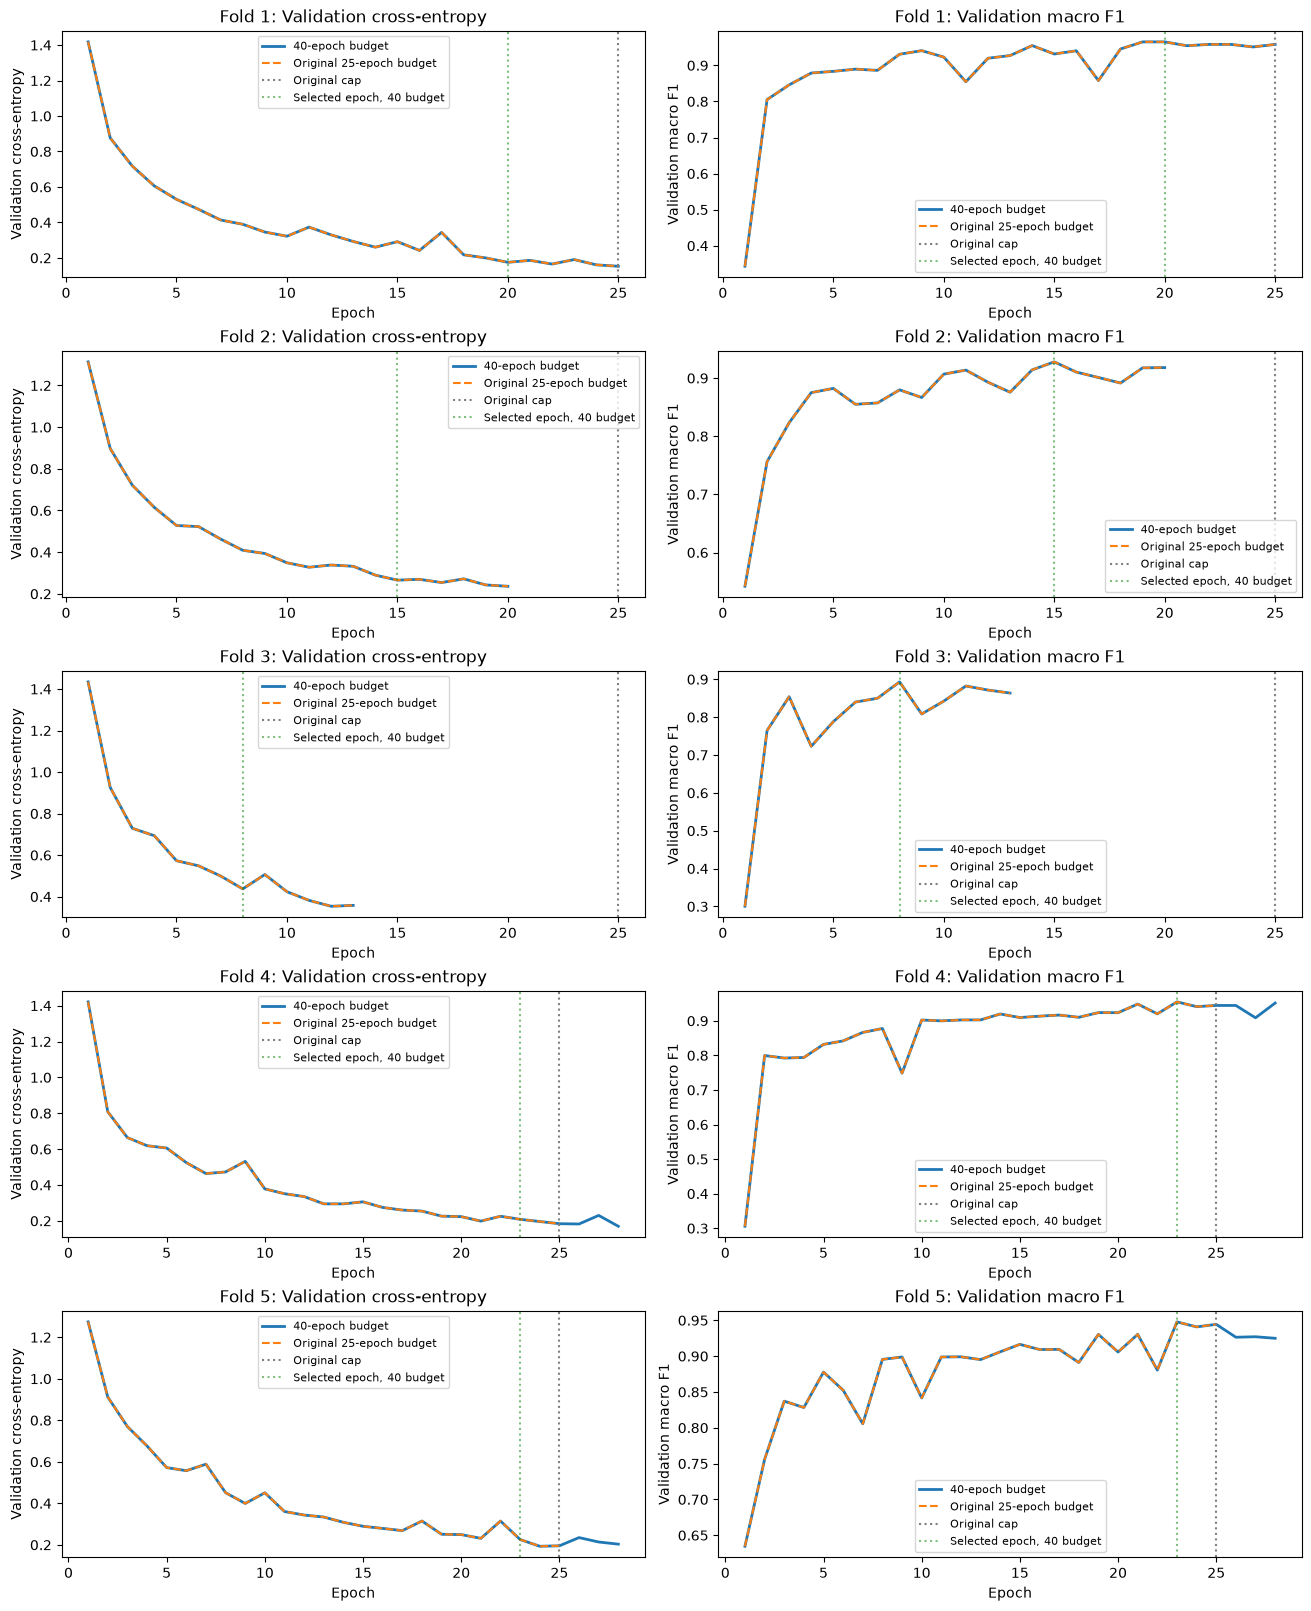

In [13]:
require('Five completed folds and exact development coverage',len(fold_results)==5 and np.all(oof_coverage==1))
fold_metrics=pd.DataFrame(fold_results).sort_values('fold').reset_index(drop=True)
history=pd.DataFrame(all_histories)
metric_names=['accuracy','precision_macro','recall_macro','f1_macro']
fold_metrics['early_stopping_triggered']=fold_metrics.stop_reason.eq('patience')
fold_metrics['hit_40_epoch_cap']=fold_metrics.epochs_run.eq(40)
fold_metrics.to_csv(RUN/'fold_metrics.csv',index=False)
comparison=baseline_metrics.merge(fold_metrics,on='fold',suffixes=('_25','_40'),validate='one_to_one')
for metric in metric_names+['fold_wall_seconds','optimisation_seconds']:
    comparison['delta_'+metric]=comparison[metric+'_40']-comparison[metric+'_25']
comparison['fold_display']=comparison.fold+1
prefix=baseline_history.merge(history,on=['fold','epoch'],suffixes=('_25','_40'),validate='one_to_one')
trajectory_columns=['online_train_loss','train_loss','train_macro_f1','validation_loss','validation_macro_f1']
prefix_errors={c:float(np.max(np.abs(prefix[c+'_40']-prefix[c+'_25']))) for c in trajectory_columns}
prefix_matches=len(prefix)==len(baseline_history) and all(v<=DECISION_RULE['prefix_tolerance'] for v in prefix_errors.values()) and (prefix.patience_used_25==prefix.patience_used_40).all() and (prefix.selected_checkpoint_25==prefix.selected_checkpoint_40).all()
write_json(RUN/'common_prefix_reproducibility.json',{'matches':bool(prefix_matches),'environment_matches':environment_matches,'matched_epochs':len(prefix),'original_epochs':len(baseline_history),'maximum_absolute_errors':prefix_errors})
extra=history.loc[history.epoch.gt(25)].groupby('fold')[['fit_seconds','train_diagnostic_seconds','validation_seconds']].sum().sum(axis=1)
comparison['measured_post25_compute_seconds']=comparison.fold.map(extra).fillna(0)
comparison['material_improvement_with_truncation']=comparison.delta_f1_macro.ge(0.005)&comparison.stop_reason_25.eq('epoch_limit')&comparison.best_epoch_40.gt(25)
comparison.to_csv(RUN/'paired_25_vs_40_fold_results.csv',index=False)
summary=pd.DataFrame([{'metric':m,'mean_25':baseline_metrics[m].mean(),'sd_25':baseline_metrics[m].std(ddof=1),'mean_40':fold_metrics[m].mean(),'sd_40':fold_metrics[m].std(ddof=1),'mean_paired_delta':comparison['delta_'+m].mean(),'sd_paired_delta':comparison['delta_'+m].std(ddof=1)} for m in metric_names])
summary.to_csv(RUN/'mean_sd_and_paired_deltas.csv',index=False)
display(comparison[['fold_display','best_epoch_25','best_epoch_40','epochs_run_40','early_stopping_triggered','hit_40_epoch_cap']+[m+'_40' for m in metric_names]+['delta_f1_macro','delta_fold_wall_seconds','measured_post25_compute_seconds']])
display(summary)
fig,axes=plt.subplots(5,2,figsize=(13,16),layout='constrained')
for fold in range(5):
    old=baseline_history.loc[baseline_history.fold.eq(fold)]
    new=history.loc[history.fold.eq(fold)]
    for col,key,label in [(0,'validation_loss','Validation cross-entropy'),(1,'validation_macro_f1','Validation macro F1')]:
        ax=axes[fold,col]
        ax.plot(new.epoch,new[key],label='40-epoch budget',linewidth=2)
        ax.plot(old.epoch,old[key],label='Original 25-epoch budget',linestyle='--')
        ax.axvline(25,color='grey',linestyle=':',label='Original cap')
        ax.axvline(int(fold_metrics.loc[fold,'best_epoch']),color='green',alpha=.5,linestyle=':',label='Selected epoch, 40 budget')
        ax.set(title=f'Fold {fold+1}: {label}',xlabel='Epoch',ylabel=label)
        ax.legend(fontsize=8)
fig.savefig(RUN/'validation_loss_f1_25_vs_40.png',dpi=150)
plt.show();plt.close(fig)


## Apply the predeclared rule and preserve all evidence
The acceptance record verifies source immutability, exact fold coverage, finite results, checkpoint integrity, declaration integrity and development-only access. No test file is opened to assert that it stayed untouched. Access evidence combines preventive enforcement with a complete log of dataset opens in this kernel.

In [14]:
mean_delta=float(comparison.delta_f1_macro.mean())
natural=int((fold_metrics.early_stopping_triggered & ~fold_metrics.hit_40_epoch_cap).sum())
material=int(comparison.material_improvement_with_truncation.sum())
if not prefix_matches or not environment_matches:
    decision='retain 25 provisionally; reproducibility qualification prevents a clean cap-only attribution'
    chosen_cap=25; adequacy='inconclusive'
elif material>=2:
    decision='adopt 40; several previously truncated folds materially improved'
    chosen_cap=40; adequacy='original cap materially restrictive'
elif abs(mean_delta)<=0.002 and not comparison.delta_f1_macro.ge(0.005).any() and natural>=3:
    decision='retain 25; negligible improvement with natural validation plateaus'
    chosen_cap=25; adequacy='25 adequate under this bounded check'
else:
    decision='retain 25 provisionally; mixed evidence, adequacy inconclusive'
    chosen_cap=25; adequacy='inconclusive'
require('Finite fold metrics and trajectories', np.isfinite(fold_metrics[metric_names]).all().all() and np.isfinite(history[trajectory_columns]).all().all())
require('Epoch budget respected',fold_metrics.epochs_run.between(1,40).all())
require('Original sources unchanged',all(file_sha(path)==source_hashes[name] for name,path in ARTIFACTS.items()))
require('Decision rule unchanged since predeclaration',file_sha(RUN/'predeclared_decision_rule.json')==declaration_sha)
require('Only development images decoded',len(image_access)==1439 and set(image_access)==set(ALLOWED_PATHS))
require('Every audited raw-data open was development-only',all(os.path.normcase(r['path']) in allowed_absolute for r in raw_open_audit))
require('Exactly the deliberate unknown-path audit denial',len(denied_raw_opens)==1)
registry=pd.DataFrame(evaluation_registry)
require('Selected validation predictions cover development only',len(registry)==1439 and registry.path.is_unique and set(registry.path)==set(ALLOWED_PATHS))
for fold in range(5):
    require(f'Fold {fold} checkpoint intact',file_sha(RUN/'checkpoints'/f'fold_{fold}_best.pt')==fold_metrics.loc[fold,'checkpoint_sha256'])
pd.DataFrame(raw_open_audit).to_csv(RUN/'raw_dataset_open_audit.csv',index=False)
pd.DataFrame(denied_raw_opens).to_csv(RUN/'denied_dataset_open_audit.csv',index=False)
pd.DataFrame({'path':image_access}).to_csv(RUN/'development_image_decode_log.csv',index=False)
registry.to_csv(RUN/'selected_development_validation_access.csv',index=False)
predictions=development[['path','class_name','validation_fold']].copy()
predictions['predicted_class']=[CLASSES[i] for i in oof_predictions]
predictions.to_csv(RUN/'development_oof_predictions.csv',index=False)
pd.DataFrame(CHECKS).to_csv(RUN/'acceptance_checks.csv',index=False)
timing={'original_25_cv_wall_seconds':float(baseline_metrics.fold_wall_seconds.sum()),'sensitivity_40_cv_wall_seconds':float(fold_metrics.fold_wall_seconds.sum()),'historical_wall_difference_seconds':float(comparison.delta_fold_wall_seconds.sum()),'measured_post25_compute_seconds':float(comparison.measured_post25_compute_seconds.sum()),'extra_epochs':int(fold_metrics.epochs_run.sum()-baseline_metrics.epochs_run.sum()),'scope':'CV only; historical timing includes load variation; post25 compute excludes checkpoint I/O'}
result={'status':'PASS','baseline_run':BASE.name,'sensitivity_run':RUN.name,'decision':decision,'adequacy':adequacy,'chosen_max_epochs':chosen_cap,'mean_macro_f1_delta':mean_delta,'material_previously_truncated_folds':material,'natural_patience_stops_before_40':natural,'common_prefix_matches':bool(prefix_matches),'environment_matches':environment_matches,'summary':summary.to_dict(orient='records'),'timing':timing,'test_images_opened':0,'test_evaluation_performed':False,'test_predictions_inspected':False,'completed_folds':5,'source_hashes':source_hashes,'predeclaration_sha256':declaration_sha}
write_json(RUN/'result.json',result)
write_json(RUN/'training_time_comparison.json',timing)
final_config=dict(CONFIG,max_epochs=chosen_cap)
selected_epochs=baseline_metrics.best_epoch if chosen_cap==25 else fold_metrics.best_epoch
write_json(RUN/'final_cnn_budget_specification.json',{'config':final_config,'decision':decision,'refit_epoch_rule':CONFIG['refit_epoch_rule'],'derived_refit_epochs':int(math.ceil(float(np.median(selected_epochs)))),'refit_performed_in_this_notebook':False,'reference_run_for_selected_epochs':BASE.name if chosen_cap==25 else RUN.name})
lines=['# CNN epoch-cap sensitivity: measured interpretation','',f'Baseline: {BASE.name}. Sensitivity: {RUN.name}.','',f'**Decision: {decision}.**','',f'Mean macro F1 changed by {mean_delta:+.6f}. {material} folds met the predeclared material-improvement-plus-truncation criterion; {natural}/5 stopped naturally before 40.', '', '| Metric | 25 mean ± SD | 40 mean ± SD | Mean paired delta |','|---|---:|---:|---:|']
for r in summary.itertuples(): lines.append(f'| {r.metric} | {r.mean_25:.6f} ± {r.sd_25:.6f} | {r.mean_40:.6f} ± {r.sd_40:.6f} | {r.mean_paired_delta:+.6f} |')
lines+=['','| Fold | Best epoch 25 / 40 | Epochs run 40 | Patience triggered | Hit 40 | Macro F1 40 | Delta F1 |','|---|---:|---:|---|---|---:|---:|']
for r in comparison.itertuples(): lines.append(f'| {r.fold+1} | {r.best_epoch_25} / {r.best_epoch_40} | {r.epochs_run_40} | {r.early_stopping_triggered} | {r.hit_40_epoch_cap} | {r.f1_macro_40:.6f} | {r.delta_f1_macro:+.6f} |')
lines+=['',f'Historical CV wall time: {timing["original_25_cv_wall_seconds"]:.2f}s versus {timing["sensitivity_40_cv_wall_seconds"]:.2f}s; difference {timing["historical_wall_difference_seconds"]:+.2f}s. Measured computation after epoch 25: {timing["measured_post25_compute_seconds"]:.2f}s across {timing["extra_epochs"]} extra epochs. Historical timing differences are confounded by machine load.', '',f'Common-prefix reproduction: {bool(prefix_matches)}. Environment match: {environment_matches}. Zero test images opened, zero test predictions inspected, and no test evaluation. The audit hook permitted only development dataset reads; the synthetic prohibited request was rejected before access. The manifest supplied boundary metadata only. Evidence is scoped to this execution, not other processes or earlier EDA.', '', 'A patience stop indicates a local plateau under the fixed macro-F1 rule, not global convergence. Validation loss was recorded throughout and did not determine checkpoint selection. The same validation folds influence checkpoint and budget selection; these are descriptive development results with selection optimism. Fold SD is not an uncertainty interval. One seed per fold does not separate seed and partition variation. No significance or equivalence claim is made. No additional caps, hyperparameter changes or final test access followed this result.', '', 'The final budget specification preserves the original ceiling-of-median refit rule. No refit was performed here. All original and new results are retained, including adverse outcomes.']
report='\n'.join(lines)
(RUN/'sensitivity_interpretation.md').write_text(report,encoding='utf-8')
from IPython.display import Markdown
display(Markdown(report))
write_json(RUN/'status.json',{'status':'PASS','completed_folds':5,'test_evaluation_performed':False})
write_json(RUN/'progress.json',{'stage':'complete','status':'PASS'})
write_json(REPORTS/'04a_cnn_epoch_sensitivity_latest.json',{'run_directory':RUN.relative_to(ROOT).as_posix(),'result_sha256':file_sha(RUN/'result.json'),'status':'PASS'})
print('Saved:',RUN)


# CNN epoch-cap sensitivity: measured interpretation

Baseline: 04_cnn_20260925T222923_890724Z. Sensitivity: 04a_cnn_epoch_sensitivity_20260926T000504_973861Z.

**Decision: retain 25; negligible improvement with natural validation plateaus.**

Mean macro F1 changed by -0.000000. 0 folds met the predeclared material-improvement-plus-truncation criterion; 5/5 stopped naturally before 40.

| Metric | 25 mean ± SD | 40 mean ± SD | Mean paired delta |
|---|---:|---:|---:|
| accuracy | 0.937464 ± 0.028826 | 0.937464 ± 0.028826 | +0.000000 |
| precision_macro | 0.941295 ± 0.026107 | 0.941295 ± 0.026107 | +0.000000 |
| recall_macro | 0.937500 ± 0.028842 | 0.937500 ± 0.028842 | +0.000000 |
| f1_macro | 0.937747 ± 0.028422 | 0.937747 ± 0.028422 | -0.000000 |

| Fold | Best epoch 25 / 40 | Epochs run 40 | Patience triggered | Hit 40 | Macro F1 40 | Delta F1 |
|---|---:|---:|---|---|---:|---:|
| 1 | 20 / 20 | 25 | True | False | 0.965152 | +0.000000 |
| 2 | 15 / 15 | 20 | True | False | 0.927876 | -0.000000 |
| 3 | 8 / 8 | 13 | True | False | 0.893120 | +0.000000 |
| 4 | 23 / 23 | 28 | True | False | 0.954774 | -0.000000 |
| 5 | 23 / 23 | 28 | True | False | 0.947815 | +0.000000 |

Historical CV wall time: 712.73s versus 741.73s; difference +29.00s. Measured computation after epoch 25: 38.39s across 6 extra epochs. Historical timing differences are confounded by machine load.

Common-prefix reproduction: True. Environment match: True. Zero test images opened, zero test predictions inspected, and no test evaluation. The audit hook permitted only development dataset reads; the synthetic prohibited request was rejected before access. The manifest supplied boundary metadata only. Evidence is scoped to this execution, not other processes or earlier EDA.

A patience stop indicates a local plateau under the fixed macro-F1 rule, not global convergence. Validation loss was recorded throughout and did not determine checkpoint selection. The same validation folds influence checkpoint and budget selection; these are descriptive development results with selection optimism. Fold SD is not an uncertainty interval. One seed per fold does not separate seed and partition variation. No significance or equivalence claim is made. No additional caps, hyperparameter changes or final test access followed this result.

The final budget specification preserves the original ceiling-of-median refit rule. No refit was performed here. All original and new results are retained, including adverse outcomes.

Saved: C:\Scripts\industrial-defect-intelligence\outputs\experiments\04a_cnn_epoch_sensitivity_20260926T000504_973861Z


## Review of the measured trajectories

The 25-epoch and 40-epoch budgets both produced mean validation macro F1 of 0.937747 with fold SD 0.028422 (ddof=1). The mean paired change was -2.220446e-17, effectively zero. The tiny positive and negative fold differences, including displayed negative zero, are numerical round-off rather than meaningful changes in performance. All 108 shared epochs reproduced within 1.12e-16, consistent with CSV floating-point round-trip differences, and the recorded environments matched.

No fold selected a later checkpoint under the 40-epoch ceiling. Selected epochs remained [20, 15, 8, 23, 23] for folds 1 to 5, with selected macro F1 values of [0.965152, 0.927876, 0.893120, 0.954774, 0.947815]. All five folds stopped naturally through the unchanged five-epoch patience rule at epochs [25, 20, 13, 28, 28]; none reached 40. Only folds 4 and 5 continued beyond epoch 25, adding three epochs each, and neither improved on its selected epoch-23 macro F1.

Fold 4: validation loss was 0.184140 at epoch 25 and 0.169792 at epoch 28; validation macro F1 was 0.944479 and 0.951457, respectively. Although both endpoint measures improved, none of epochs 26 to 28 surpassed the selected epoch-23 macro F1 of 0.954774.

Fold 5: validation loss was 0.195320 at epoch 25 and 0.203196 at epoch 28; validation macro F1 was 0.944408 and 0.924919, respectively. None of epochs 26 to 28 surpassed the selected epoch-23 macro F1 of 0.947815.

The loss curves do not establish a flat loss plateau: lower cross-entropy need not yield higher macro F1. Validation loss did not determine checkpoint selection or stopping. The adequacy conclusion is specific to the declared macro-F1 early-stopping and checkpoint rule. It does not prove global convergence, show that all optimisation had ceased, or rule out later improvements under another stopping policy. Keeping early stopping unchanged is essential to the controlled question.

The original CV wall time was 712.73 seconds and the sensitivity CV wall time was 741.73 seconds, a historical difference of +29.00 seconds. Measured computation after epoch 25 was 38.39 seconds across six extra epochs: 19.00 seconds for fold 4 and 19.39 seconds for fold 5. This within-run measure includes optimisation and training/validation diagnostic passes but excludes checkpoint I/O. Historical wall-time subtraction also reflects machine load variation and cannot isolate the cost of the extension.

Retain the original 25-epoch maximum. The effectively zero mean change, absence of any material fold improvement and five natural patience stops before 40 satisfy the predeclared adequacy rule. This is a bounded training-adequacy sensitivity check, not a statistical equivalence test or an independent test estimate. The unchanged ceiling-of-median rule gives 20 epochs for final development refitting; no refit was performed here and the existing final development checkpoint was not replaced. All 1,511 acceptance checks passed and all 14 code cells completed without error. No locked test images were opened, no test predictions were inspected and no test evaluation was performed.
